### **Concurrency**

Concunrency refers to a sequence of task run in order where each can stop at certain time and the computer interleaves ( CPU can switch to a different task at the middle of a running task and comeback to continue it later). The state of each task/ process is saved and can be restored where it was left/ interrupted.


In Concurrency, the words tasks, threads and process are used but they have different meanings but on higher level the terms can be used interchangably.

On the other hand running a sequence of tasks at the same time is refered to as parrallelism

Threads and Asynchronous tasks always run on a single processor, which means they can run only one at a time. They just find a way to take turns to speed up overall process in some cases.

1. Process: A process is an independent program in execution. It has it's own memory space, system resources and execution state. every process has one main thread of execution (primary thread that runs the code). Processes are independent of each other and do not share memory space directly undless inter-process communication is required to share data between processes.
2. Thread: A thread is a smaller unit of execution inside a process. A process can have one thread (single-threaded) or many (multi-threaded). It's a Subunit of a process. Threads within the same process share the same memory space and resources which allows for faster communication and less overhead compared to inter-process communication.
3. Task: A task It is typically an abstraction is unit of work think of it like a to-do-item They don't need to be in a process or they don't require a process to exist. So basically a task is waiting to be executed by a thread. Tasks can be managed by frameworks or runtime environments.

**Example: Process, Threads and Tasks**

Imagine we are running a web server.
1. Process: The web server it self is a process, It is an instance of a running program that has it own memory space, the OS assigns resources (like CPU time, memory) to this web server process.

2. Threads: The running web server is active (running) it listens for incomming network connections (HTTP Request) and manages all resources necessary to serving those request using threads. It could use a singke thread per request (eg Apache's worker MPM), each incoming request handled by a separate thread within the same process and sends the request's response back to the user. It could also use a Thread pool where a fixed number of threads are created ahead of time and these threads are reused to handle incoming requests rather than creating for each request.

3. A Task is an abstraction. It's a unit of work waiting to be picked up by a thread (or sometimes not). The web server schedules tasks (e.g., to fetch data from a database or read from a file), and the tasks can run concurrently without blocking the main thread. When a task is waiting for data (say, waiting for a file download or a database query to finish), it gives up control to the event loop, which then runs another task until the data is ready.

A multi-threaded program can do different things at the same time by running it's thread concurrently.

Threads in most languages often run in parrallel. But not the case in python because of Python Global Interpreter Lock (GIL). The Global lock interpreter is a lock (mutex - Mutually exclusive) that allows one thread to utilize the python intepreter (i.e execute python bytecode) at a time within a single process. This means that even if you have multiple threads running in a Python program, only one thread can execute Python code (bytecode) at any given time, which prevents true parallelism on multi-core systems. Well the GIL is not just there to be a d*ck for multi-threaded programs. to see what problem the GIL was created to solve read: [link](https://realpython.com/python-gil/)



The way a multithread program works is that the Operation System knows about each thread and can interrupt it at any time to start running a different thread. This mechanism occurs in processes and it's called `preemptive multitasking` since the operating sysytem can **preempt** your thread or process to make the switch betweeb threads consequently ensuring fair time-sharing.

`Asynchronous tasks` use `cooperative multitasking` (where the task decide when to give up control and conitnue (i.e pre-computed in code logic)) instead of `premtive multitasking` (i.e Operating decides when to switch tasks external to python). The tasks cooperate with each other and let each other know when they are ready to switch. Tasks don't require the operation system to run them unlike threads. they are just piece of code waiting to be executed by the OS.

### **Parallelism**

Since we know that concurrency happens on a single processor. In other to utilize all the cores our CPU has to execute separate process (multiple programs). One way to think of it is that each process runs in its own python interpreter. Runnning on a different core means that they can actually run at the same time.

Both `threading` and `multiprocessing` represent fairly low-level building blocks in concurrent programs. In practice, you can often replace them with `concurrent.futures`, which provides a higher-level interface for both modules. On the other hand, `asyncio` offers a bit of a different approach to concurrency, which you’ll dive into later.

`Multiprocessing` while being parrallel can still be preemptive (because we would expect that since multiple processes occur in different cores they shoudn't have to wait for each other but in real world systems things aren't always ideal. We won't always have the same number of cores and processes. Say we have 4 cores and 20 processes. Even if processes will run in parrallel (multiprocessing) preemption will still occurs as we don't have enough cores for 20 processes).

|Myths|Clarification|
|-----|-------------|
|Multiple cores means no need for preemption|Not always. Preemption is still needed for fairness, limits, and control|
|Independent processes don’t interfere|True logically, but they still compete for shared hardware|
|Only one thing runs on one core at a time|True, so if you have more tasks than cores, you must preempt|

### **When is Concurrency Useful ?**

Concurrency makes a differece in two types of problems:
1. I/O Bound
2. CPU-Bound


#### **I/O Bound problems**

I/O means Input or Output. Sometimes our program needs to input to or output from some external resource and these slows down our program because it frequently waits for input / output (I/O) from external resources (example of things slower than your cpu are legions (like large amount of objects being rendered and processed by the game engine or a huge volume of data packets or traffic in a network or large number of peripheral  devices, monitors, printers and storage devices) most times our program don't interact with things as massive as this) In reality most things that slows things in our program is it interaction file systems and network connections.



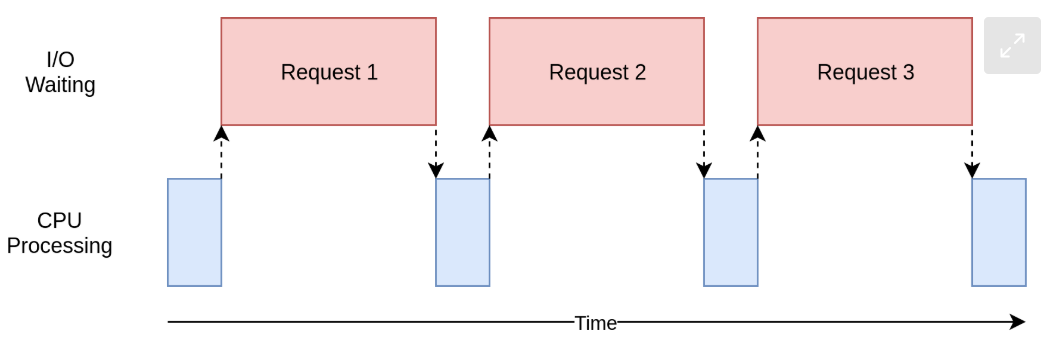

from the illustration above we see when our program runs relative to these I/O operations is small and each I/O operations takes different time (the immage is not drawn to scale) so our program will evently spend most of its time waiting. 

#### **CPU bound Problems**

They are some programs that don't require I/O operation but they run our CPU and they do significant computation (here the resource limiting the speed of our program is our CPU). They will eventually significantly more time than our other programs.

Different forms of concurrency works for better or worse with I/O - bound and CPU - bound programs. Adding concurrency to our code can introduce some complexity to our code so we will have to know when concurrency potentially speed up our code and it's worth the extra effort.

### **Speeding Up CPU and I/O Bound Program**

For practice we will use a common problem in I/O bound programs: _Downloading Content over the network_. we'll be using web pages from websites (but it could be any network traffic in reality).

**Synchronous Verion**

In [2]:
import time
import requests

def main():
    sites = [
        "https://www.jython.org",
        "http://olympus.realpython.org/dice",
    ] * 80
    start_time = time.perf_counter()
    download_all_sites(sites)
    duration = time.perf_counter() - start_time
    print(f"Downloaded {len(sites)} sites in {duration} seconds")

def download_all_sites(sites):
    with requests.Session() as session:
        for url in sites:
            download_site(url, session)
def download_site(url, session):
    with session.get(url) as response:
        print(f"Read {len(response.content)} bytes from {url}")

if __name__ == "__main__":
    main()

Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice
Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice
Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice
Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice
Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice
Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice
Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice
Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice
Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice
Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice


#### **Multithreaded version**

In [ ]:
import threading
import time
from concurrent.futures import ThreadPoolExecutor
import requests

thread_local = threading.local()

def main():
    sites = [
        "https://www.jython.org",
        "http://olympus.realpython.org/dice",
    ] * 80
    start_time =  time.perf_counter()
    download_all_sites(sites)  
    duration = time.perf_counter() - start_time
    print(f"Downloaded {len(sites)} sites in {duration} seconds")

def download_all_sites(sites):
    # python standard libary implements ThreadPoolExecutor as a context manager
    with ThreadPoolExecutor(max_workers=5) as executor:
        # let the executor call download site on your behave instead of doing it manually with for loops
        executor.map(download_site, sites)
        # the line above takes care of distributing the workload across the available threads allowing each to handle different sites concurrently.
        # map accepts a funtion to be executed on each data item and the collection of data items to be processed.
def download_site(url):
    session =  get_session_for_thread()
    with session.get(url) as response:
        print(f"Read {len(response.content)} bytes from {url}")

def get_session_for_thread():
    if not hasattr(thread_local, "session"):
        thread_local.session = requests.Session()
    return thread_local.session

if __name__ == "__main__":
    main()

Read 272 bytes from http://olympus.realpython.org/dice
Read 272 bytes from http://olympus.realpython.org/dice
Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice
Read 10966 bytes from https://www.jython.org
Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice
Read 10966 bytes from https://www.jython.org
Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice
Read 272 bytes from http://olympus.realpython.org/dice
Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice
Read 10966 bytes from https://www.jython.org
Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice
Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice
Read 10966 bytes from https://www.jython.org
Read 272 bytes from http://olympus.realpython.org/dice


In our code, the `ThreadpoolExecutor` instantiates a pool of threads as executor, where each thread can run concurrently. the OS controls how each of the threads in executor will run and requests are executed in the pools.


The ThreadPoolExecutor creates and manages a fixed pool of worker threads that can run tasks concurrently. When you submit tasks (like HTTP requests) to the pool, these threads pick up and execute the tasks. The operating system’s scheduler controls when and how each thread runs on the CPU cores, handling context switching and time slicing to share processor time fairly among threads. Because network requests are typically I/O-bound and spend time waiting for responses, using a thread pool allows multiple requests to be handled efficiently by overlapping waiting times. This improves overall throughput, even if the threads don’t always run in true parallelism (which depends on the number of CPU cores available).

requests.Session is not thread-safe because it keeps internal mutable state that multiple threads can access and modify at the same time, causing race conditions and data corruption if shared without proper synchronization.

A piece of code or object is thread-safe if it behaves correctly when accessed from multiple threads at the same time, without causing bugs or corrupting data.

If something is not thread-safe, simultaneous access from multiple threads can lead to unexpected problems like:

1. Race conditions (threads overwrite each other's data)

2. Corrupted internal state

3. Crashes or inconsistent behavior




An example of race condition:

1. Thread A reads a record from the database.

2. Before Thread A finishes processing, the OS switches to Thread B.

3. Thread B overwrites or updates the same record in the database.

4. The OS switches back to Thread A, which continues using the old (stale) data it read earlier.

5. This can cause inconsistent results, errors, or corrupted data because Thread A worked with outdated information.



If threads share the same session instance, since `requests.Session` isn't thread-safe, concurrent calls to session.get() can interfere with each other.

You might see errors, failed requests, or inconsistent output — especially under heavy load or many threads.

There are several strategies for making data access thread-safe. One of them is to use a thread-safe data structure, such as a `queue.Queue`, `multiprocessing.Queue`, or an `asyncio.Queue`. These objects use low-level primitives like `lock objects` to ensure that only one thread can access a block of code or a bit of memory at the same time. You’re using this strategy indirectly by way of the `ThreadPoolExecutor object`.



In our code we used another method to solve this issue, this is called `thread-local storage`. when we call `threading.local` we creare a global variable like object which is set as unique attributes for every threads.

So when we call `get_session_thread()` we check if a thread has it own session and if not we assign it one which last through out it life-time.

#### **Asynchronous Version**